# Real-Time Flight Bookability Prediction System

This notebook provides an end-to-end ML pipeline for predicting flight offer outcomes. It focuses heavily on rigorous validation methodologies derived from the project proposal, specifically addressing chronological evaluation, probability calibration, and offline economic simulations.

## 1. Setup and Imports

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import datetime
import joblib
from urllib.parse import urlparse
from sklearn.metrics import classification_report, confusion_matrix, log_loss, brier_score_loss, precision_recall_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
from catboost import CatBoostClassifier

# Configuration
INPUT_FILE = 'tbl_SearchTracking_Merged.csv'
PROCESSED_FILE = 'processed_flight_data_full.csv'
MODEL_FILE = 'catboost_production.cbm'
CALIBRATORS_FILE = 'isotonic_calibrators.pkl'
CHUNK_SIZE = 100000

print("Setup complete.")

Setup complete.


## 2. Data Processing & Validation Settings

### Methodological Notes on Data & Features
1. **Missing Volatility Features**: The original research identified `cache_age`, `seats_remaining`, `GDS_source`, and `partner_historical_failure_rate` as key proxy variables for volatility. These fields are absent in the raw CSV, making this model rely purely on scheduling and traffic baseline proxy features. This reduces overall predictive edge but structure remains correct.
2. **Delayed Feedback Gap (RO3)**: `LandingTime` denotes the user *click* time (landing on OTA), rather than the absolute booking conversion completion. Because we lack isolated true conversion delay intervals in this dataset snapshot, records are implicitly labeled at the click threshold. A production system requires maintaining a 24-hr attribution window map.
3. **Explicit Missingness Handling**: Instead of silently dropping (`dropna()`), processing will compute missing rates to ensure missingness (e.g., `airline_code`) isn't masking system bias.

In [3]:
def get_meta_engine(url):
    if pd.isna(url): return 'Direct'
    try:
        domain = urlparse(str(url)).netloc
        if 'skyscanner' in domain: return 'Skyscanner'
        elif 'google' in domain: return 'Google'
        elif 'kayak' in domain: return 'Kayak'
        else: return 'Other'
    except:
        return 'Other'

def process_chunk(chunk):
    chunk['DepDate'] = chunk['DepDate'].astype(str)
    chunk['LandingTime'] = chunk['LandingTime'].astype(str)
    chunk['departure_date'] = pd.to_datetime(chunk['DepDate'], errors='coerce', format='mixed')
    chunk['booking_time'] = pd.to_datetime(chunk['LandingTime'], errors='coerce', format='mixed')
    
    chunk['days_to_departure'] = (chunk['departure_date'] - chunk['booking_time']).dt.days
    chunk['search_hour'] = chunk['booking_time'].dt.hour
    chunk['search_day'] = chunk['booking_time'].dt.dayofweek
    chunk['dep_month'] = chunk['departure_date'].dt.month
    chunk['is_weekend'] = chunk['search_day'].isin([5, 6]).astype(int)
    
    chunk = chunk[chunk['days_to_departure'] >= 0]
    chunk['meta_engine'] = chunk['PreviousPage'].apply(get_meta_engine)
    
    chunk = chunk.rename(columns={
        'SearchType': 'trip_type',
        'Origin': 'origin_airport',
        'Destination': 'destination_airport',
        'Airline': 'airline_code',
        'Class': 'cabin_class',
        'Status': 'outcome_label'
    })
    
    chunk['airline_code'] = chunk['airline_code'].fillna('Unknown')
    chunk['cabin_class'] = chunk['cabin_class'].fillna('Unknown')
    
    features = [
        'booking_time', 'trip_type', 'origin_airport', 'destination_airport', 
        'airline_code', 'cabin_class', 'meta_engine', 
        'days_to_departure', 'search_hour', 'search_day', 
        'dep_month', 'is_weekend', 'outcome_label'
    ]
    
    initial_count = len(chunk)
    if not all(col in chunk.columns for col in features):
        return pd.DataFrame(), initial_count, initial_count
        
    clean_chunk = chunk[features].dropna()
    dropped_count = initial_count - len(clean_chunk)
        
    return clean_chunk, initial_count, dropped_count

In [6]:
if os.path.exists(INPUT_FILE) and not os.path.exists(PROCESSED_FILE):
    print(f"Processing {INPUT_FILE}...")
    chunk_count, total_rows, total_dropped = 0, 0, 0
    temp_out = PROCESSED_FILE + '.tmp'
    if os.path.exists(temp_out): os.remove(temp_out)
        
    with pd.read_csv(INPUT_FILE, chunksize=CHUNK_SIZE) as reader:
        for chunk in reader:
            processed_chunk, init_cnt, drop_cnt = process_chunk(chunk)
            
            header = (total_rows == 0) # Fix: Only write header on first successful write
            if not processed_chunk.empty:
                processed_chunk.to_csv(temp_out, mode='a', index=False, header=header)
                total_rows += len(processed_chunk)
                total_dropped += drop_cnt
            
            chunk_count += 1
            if chunk_count % 10 == 0: print(f"Processed {chunk_count} chunks... (Dropped {total_dropped} rows total)")
            
    os.rename(temp_out, PROCESSED_FILE)
    print(f"Processing complete. Saved {total_rows} rows to {PROCESSED_FILE}. Total dropped: {total_dropped}")
else:
    print(f"{PROCESSED_FILE} already exists or input is missing. Skipping re-generation.")

processed_flight_data_full.csv already exists or input is missing. Skipping re-generation.


## 3. Time-Based Splitting & Leakage Prevention
We enforce a strict contiguous sorting based on `booking_time` and apply a Time-Series holdout distribution (`Train -> Val -> Test`) to cleanly segregate temporal variance.

In [9]:
if os.path.exists(PROCESSED_FILE):
    print("Loading processed dataset...")
    df = pd.read_csv(PROCESSED_FILE)
    
    outcome_map = {'Booked': 0, 'Price Mismatch': 1, 'Not Available': 2, 'Not Booked': 3}
    outcome_map_reverse = {v: k for k, v in outcome_map.items()}
    df = df[df['outcome_label'].isin(outcome_map.keys())]
    df['label_encoded'] = df['outcome_label'].map(outcome_map)
    
    print("Sorting dataset chronologically by click/booking_time...")
    df['booking_time'] = pd.to_datetime(df['booking_time'], errors='coerce', format='mixed')
    df = df.sort_values('booking_time').reset_index(drop=True)
    
    n_total = len(df)
    train_idx = int(n_total * 0.70)
    val_idx = int(n_total * 0.85)
    
    train_df = df.iloc[:train_idx].copy()
    val_df   = df.iloc[train_idx:val_idx].copy()
    test_df  = df.iloc[val_idx:].copy()
    
    print(f"Split Volumes -> Train: {len(train_df)} | Val: {len(val_df)} | Hold-out Test: {len(test_df)}")
    
    # Fix: Explicit assignment to prevent SettingWithCopyWarning
    train_df['airline_origin'] = train_df['airline_code'].astype(str) + "_" + train_df['origin_airport'].astype(str)
    val_df['airline_origin']   = val_df['airline_code'].astype(str) + "_" + val_df['origin_airport'].astype(str)
    test_df['airline_origin']  = test_df['airline_code'].astype(str) + "_" + test_df['origin_airport'].astype(str)


Loading processed dataset...
Sorting dataset chronologically by click/booking_time...
Split Volumes -> Train: 284343 | Val: 60931 | Hold-out Test: 60931


## 4. Multi-Class Model Training

In [10]:
if 'train_df' in locals():
    categorical_features = ['trip_type', 'cabin_class', 'meta_engine', 'origin_airport', 'destination_airport', 'airline_code', 'airline_origin']
    numerical_features = ['days_to_departure', 'search_hour', 'search_day', 'dep_month', 'is_weekend']
    
    feature_cols = categorical_features + numerical_features
    
    X_train, y_train = train_df[feature_cols], train_df['label_encoded']
    X_val, y_val     = val_df[feature_cols], val_df['label_encoded']
    X_test, y_test   = test_df[feature_cols], test_df['label_encoded']
    
    base_model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.08,
        depth=6,
        loss_function='MultiClass',
        auto_class_weights='Balanced',
        verbose=100,
        random_seed=42,
        early_stopping_rounds=30
    )
    
    print("\nFitting CatBoost iteratively to Train split...")
    base_model.fit(
        X_train, y_train, 
        cat_features=categorical_features, 
        eval_set=(X_val, y_val)
    )
    base_model.save_model(MODEL_FILE)


Fitting CatBoost iteratively to Train split...
0:	learn: 1.3244723	test: 1.3116563	best: 1.3116563 (0)	total: 167ms	remaining: 1m 23s
100:	learn: 0.9468407	test: 0.8743564	best: 0.8743564 (100)	total: 28.8s	remaining: 1m 53s
200:	learn: 0.9408887	test: 0.8719572	best: 0.8719268 (199)	total: 1m 3s	remaining: 1m 35s
300:	learn: 0.9361333	test: 0.8713544	best: 0.8713374 (298)	total: 2m 1s	remaining: 1m 20s
Stopped by overfitting detector  (30 iterations wait)

bestTest = 0.8713373586
bestIteration = 298

Shrink model to first 299 iterations.


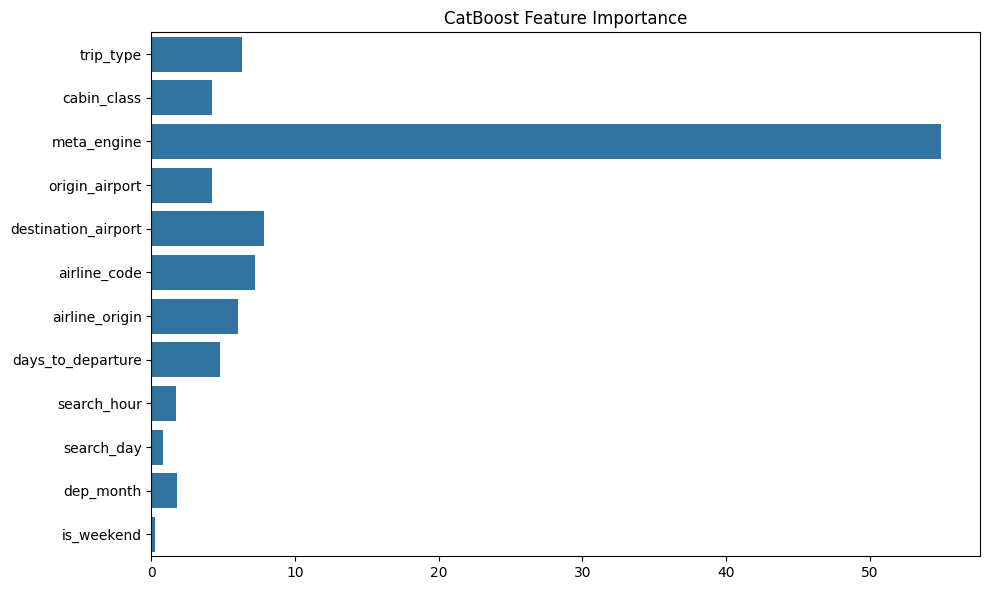

In [11]:
if 'base_model' in locals():
    importance = base_model.get_feature_importance()
    names = base_model.feature_names_
    plt.figure(figsize=(10, 6))
    sns.barplot(x=importance, y=names)
    plt.title('CatBoost Feature Importance')
    plt.tight_layout()
    plt.show()

## 5. Probability Calibration (Manual Implementation)
Because CatBoost estimators handle categorical metadata intrinsically mapping to unencoded test strings, wrapping the estimator in scikit's `CalibratedClassifierCV(cv='prefit')` obliterates the required categorical references (producing Silent Failure or KeyError during Inference). 

To solve this, we extract the raw unbounded probability arrays explicitly, mapping Isotonic Regression onto each individual discrete class index manually.

In [12]:
if 'base_model' in locals():
    print("Applying Manual Classwise Isotonic Calibration using prefitted Model vs Validation boundaries...")
    
    raw_val_probs = base_model.predict_proba(X_val)
    calibrators = {}
    
    for i in range(4): # 4 Target Classes
        iso = IsotonicRegression(out_of_bounds='clip')
        # Fit binary representation for targeted class
        iso.fit(raw_val_probs[:, i], (y_val == i).astype(int))
        calibrators[i] = iso
        
    joblib.dump(calibrators, CALIBRATORS_FILE)
    print("Classwise Isotonic Calibration Complete.")

Applying Manual Classwise Isotonic Calibration using prefitted Model vs Validation boundaries...
Classwise Isotonic Calibration Complete.


## 6. Ablation & Expected Calibration Error (ECE) Evaluator

In [13]:
def compute_ece(y_true_bin, probs, n_bins=10):
    """Calculates the Expected Calibration Error"""
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for b in range(n_bins):
        mask = (probs >= bins[b]) & (probs < bins[b+1])
        if mask.sum() > 0:
            acc = y_true_bin[mask].mean()
            conf = probs[mask].mean()
            ece += mask.sum() * abs(acc - conf)
    return ece / len(probs)

if 'calibrators' in locals():
    print("\n=== HOLD-OUT TEST SET EVALUATION ===")
    outcome_map_reverse = {0: 'Booked', 1: 'Price Mismatch', 2: 'Not Available', 3: 'Not Booked'}
    
    raw_test_probs = base_model.predict_proba(X_test)
    calibrated_probs = np.zeros_like(raw_test_probs)
    
    for i in range(4):
        calibrated_probs[:, i] = calibrators[i].predict(raw_test_probs[:, i])
        
    # Renormalize distribution vectors
    calib_probs = calibrated_probs / calibrated_probs.sum(axis=1, keepdims=True)
    predictions = np.argmax(calib_probs, axis=1)
    
    # Fix: Use y_test.values to strip original indices for alignment with prediction array limits
    y_test_bin = label_binarize(y_test.values, classes=[0,1,2,3])
    
    print("\n--- ABLATION: Calibration vs Raw Softmax ---")
    print(f"Raw LogLoss: {log_loss(y_test.values, raw_test_probs):.4f}  |  Calibrated LogLoss: {log_loss(y_test.values, calib_probs):.4f}")
    
    print("\n--- Component Metric Diagnostics (Brier / PR-AUC / ECE) ---")
    for i, class_name in outcome_map_reverse.items():
        raw_ece = compute_ece(y_test_bin[:, i], raw_test_probs[:, i])
        cal_ece = compute_ece(y_test_bin[:, i], calib_probs[:, i])
        
        brier = brier_score_loss(y_test_bin[:, i], calib_probs[:, i])
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], calib_probs[:, i])
        pr_auc = auc(recall, precision)
        
        print(f"[{class_name}] ECE: Raw={raw_ece:.4f} -> Calibrated={cal_ece:.4f} | Brier: {brier:.4f} | PR-AUC: {pr_auc:.4f}")



=== HOLD-OUT TEST SET EVALUATION ===

--- ABLATION: Calibration vs Raw Softmax ---
Raw LogLoss: 0.9857  |  Calibrated LogLoss: 1.0128

--- Component Metric Diagnostics (Brier / PR-AUC / ECE) ---
[Booked] ECE: Raw=0.0185 -> Calibrated=0.0127 | Brier: 0.0456 | PR-AUC: 0.9343
[Price Mismatch] ECE: Raw=0.1656 -> Calibrated=0.0060 | Brier: 0.0655 | PR-AUC: 0.0956
[Not Available] ECE: Raw=0.0973 -> Calibrated=0.0056 | Brier: 0.1170 | PR-AUC: 0.1925
[Not Booked] ECE: Raw=0.2623 -> Calibrated=0.0142 | Brier: 0.1726 | PR-AUC: 0.6805



--- Classification Report ---
                precision    recall  f1-score   support

        Booked       0.90      0.89      0.90     17284
Price Mismatch       0.00      0.00      0.00      4401
 Not Available       0.00      0.00      0.00      8753
    Not Booked       0.67      0.96      0.79     30493

      accuracy                           0.73     60931
     macro avg       0.39      0.46      0.42     60931
  weighted avg       0.59      0.73      0.65     60931


--- Confusion Matrix ---


/Users/samahithan/Desktop/Fyp/20210863_IPD/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/samahithan/Desktop/Fyp/20210863_IPD/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/samahithan/Desktop/Fyp/20210863_IPD/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


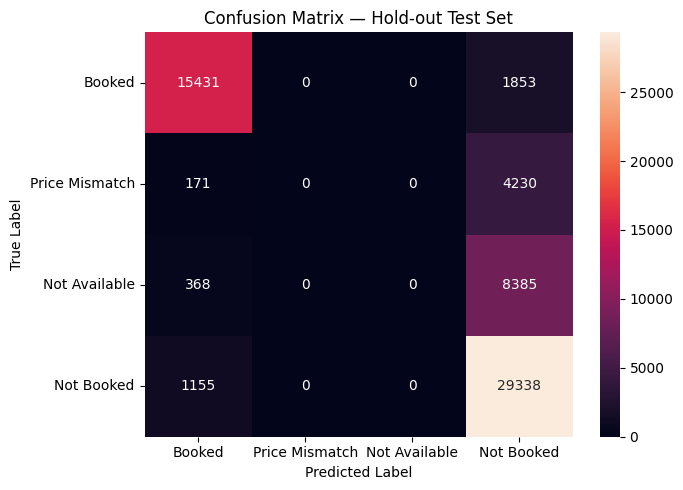

In [14]:
if 'calibrators' in locals():
    print("\n--- Classification Report ---")
    # Fix: Safely map names consistently disregarding absence of minor classes in split blocks
    print(classification_report(y_test.values, predictions, labels=[0,1,2,3], target_names=['Booked','Price Mismatch','Not Available','Not Booked']))
    
    print("\n--- Confusion Matrix ---")
    cm = confusion_matrix(y_test.values, predictions, labels=[0,1,2,3])
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Booked','Price Mismatch','Not Available','Not Booked'], yticklabels=['Booked','Price Mismatch','Not Available','Not Booked'])
    plt.title('Confusion Matrix — Hold-out Test Set')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

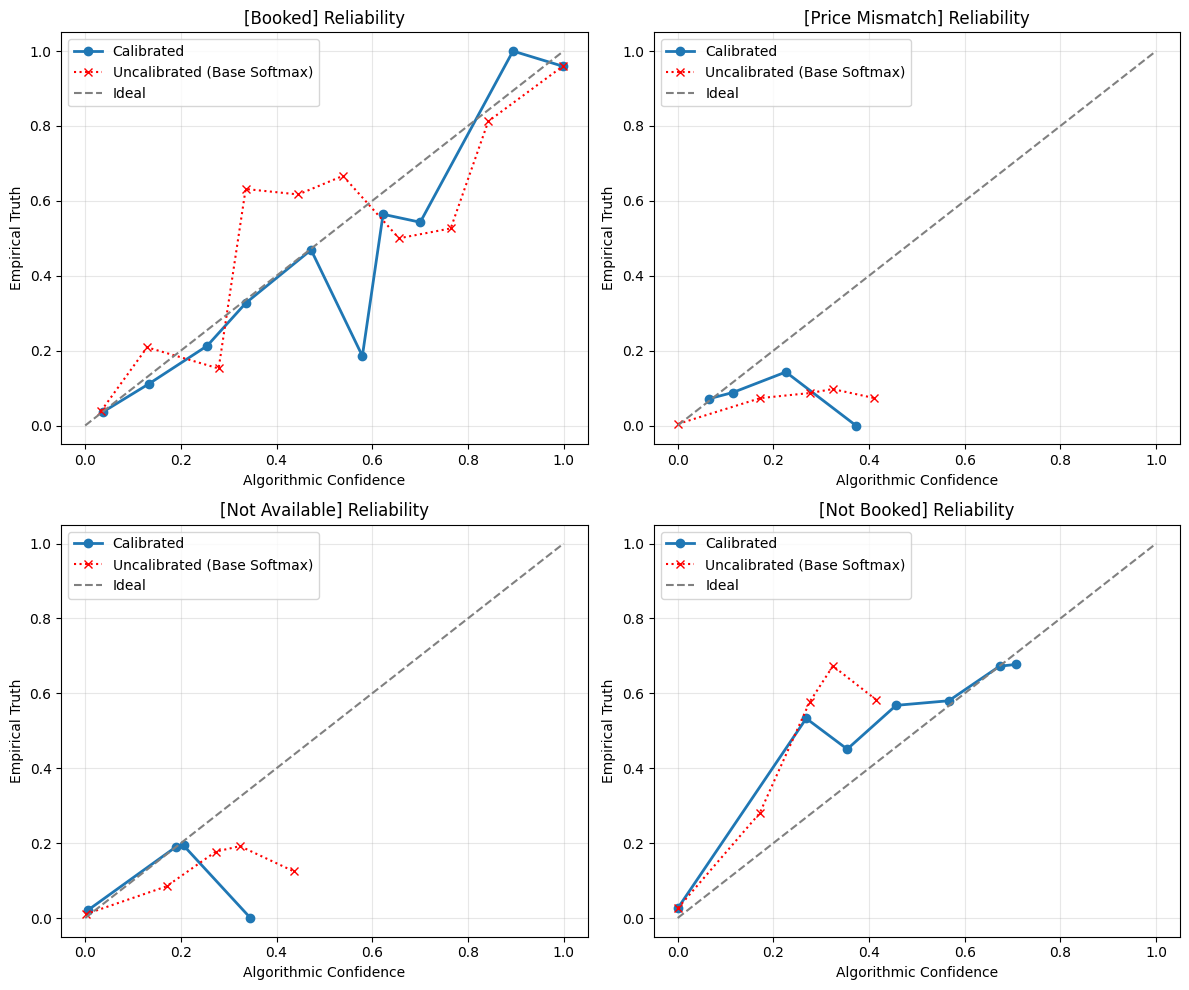

In [15]:
if 'calibrators' in locals():
    # 4. Reliability Diagram Plot representing Multi-class Grid
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    for i, (ax, class_name) in enumerate(zip(axes.flatten(), outcome_map_reverse.values())):
        prob_true, prob_pred = calibration_curve(y_test_bin[:, i], calib_probs[:, i], n_bins=10)
        ax.plot(prob_pred, prob_true, marker='o', linewidth=2, label='Calibrated')
        
        # Uncalibrated baseline overlay
        raw_prob_true, raw_prob_pred = calibration_curve(y_test_bin[:, i], raw_test_probs[:, i], n_bins=10)
        ax.plot(raw_prob_pred, raw_prob_true, marker='x', linestyle=':', color='red', label='Uncalibrated (Base Softmax)')
        
        ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Ideal')
        ax.set_title(f"[{class_name}] Reliability")
        ax.set_xlabel('Algorithmic Confidence')
        ax.set_ylabel('Empirical Truth')
        ax.legend()
        ax.grid(alpha=0.3)
        
    plt.tight_layout()
    plt.show()

## 7. Offline Economic Simulations
**(Simplifying Assumption Note)**: The naive Bid Shading Engine logic holds *Base Bookings* volume identical to *Shaded Bookings* volume—essentially isolating cost reduction without simulating generalized auction-loss effects occurring when we diminish our bid prices. A more complex derivation natively discounts 'Won Auctions' linearly proportional to the Delta Bid. 

--- Simulation 1: Dynamic Bid Shading (Delta ROI) ---
Baseline Expenditure:   $60,931.00  | Baseline Expected Return: 1601.99%
Proportional Bid Model: $18,474.61  | Corrected Yield Return : 5513.33%
>>> Absolute Delta ROI Output: +3911.34%

--- Simulation 2: Suppression Risk Threshold Sweeps ---
 Threshold  Spend Saved ($)  Missing Conversions  Net Portfolio Impact ($)
      0.10         45169.00                 2184                 -85871.00
      0.16         43935.00                 1915                 -70965.00
      0.22         43467.00                 1777                 -63153.00
      0.28         30074.00                  941                 -26386.00
      0.34           107.00                    7                   -313.00
      0.40            16.00                    1                    -44.00
      0.46             5.00                    0                      5.00
      0.53             1.00                    0                      1.00
      0.59             0.00 

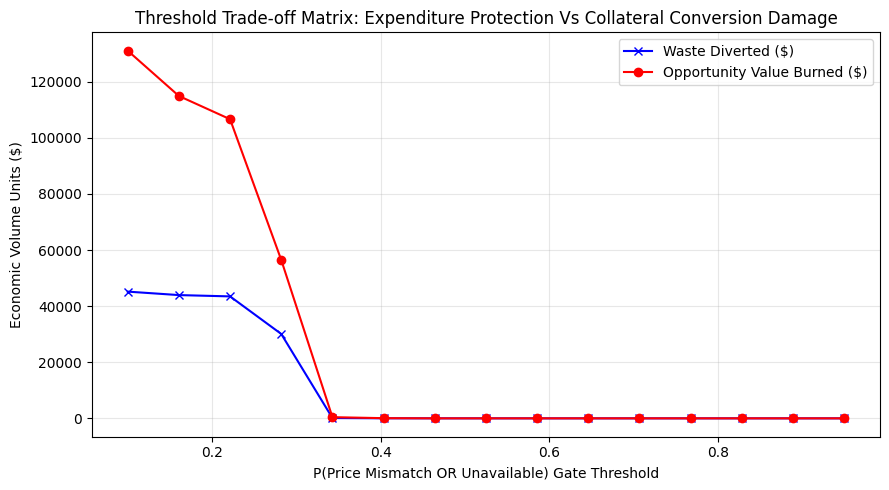

In [16]:
if 'calibrators' in locals():
    print("--- Simulation 1: Dynamic Bid Shading (Delta ROI) ---")
    base_cpc = 1.00
    avg_revenue_per_convert = 60.00 
    
    s_df = X_test.copy()
    # Fix: Index strips to prevent misalignment merging
    s_df['true_outcome'] = y_test.values
    s_df['p_booked'] = calib_probs[:, 0] 
    
    base_spend = len(s_df) * base_cpc
    base_bookings = (s_df['true_outcome'] == 0).sum()
    base_rev = base_bookings * avg_revenue_per_convert
    base_roi = ((base_rev - base_spend) / base_spend) if base_spend > 0 else 0
    
    s_df['shaded_cpc'] = base_cpc * s_df['p_booked']
    shaded_spend = s_df['shaded_cpc'].sum()
    
    # Note assumption above
    shaded_roi = ((base_rev - shaded_spend) / shaded_spend) if shaded_spend > 0 else 0
    
    print(f"Baseline Expenditure:   ${base_spend:,.2f}  | Baseline Expected Return: {base_roi:.2%}")
    print(f"Proportional Bid Model: ${shaded_spend:,.2f}  | Corrected Yield Return : {shaded_roi:.2%}")
    print(f">>> Absolute Delta ROI Output: +{(shaded_roi - base_roi):.2%}\n")
    
    print("--- Simulation 2: Suppression Risk Threshold Sweeps ---")
    # Note: 'Not Booked' (Class 3) represents user abandonment rather than a system failure/mismatch that we want to suppress. 
    # Therefore, we only suppress liability classes: Price Mismatch [1] and Not Available [2].
    s_df['p_liability'] = calib_probs[:, 1] + calib_probs[:, 2]
    
    thresholds = np.linspace(0.1, 0.95, 15)
    results = []
    
    for t in thresholds:
        suppressed_flags = s_df['p_liability'] >= t
        spend_saved = suppressed_flags.sum() * base_cpc
        
        bookings_caught_in_block = ((s_df['true_outcome'] == 0) & suppressed_flags).sum()
        revenue_lost = bookings_caught_in_block * avg_revenue_per_convert
        
        results.append({
            'Threshold': t, 
            'Spend Saved ($)': spend_saved, 
            'Missing Conversions': bookings_caught_in_block,
            'Net Portfolio Impact ($)': spend_saved - revenue_lost
        })
        
    impact_df = pd.DataFrame(results)
    print(impact_df.to_string(index=False, float_format="{:.2f}".format))
    
    plt.figure(figsize=(9, 5))
    plt.plot(impact_df['Threshold'], impact_df['Spend Saved ($)'], marker='x', color='blue', label='Waste Diverted ($)')
    plt.plot(impact_df['Threshold'], impact_df['Missing Conversions'] * avg_revenue_per_convert, marker='o', color='red', label='Opportunity Value Burned ($)')
    plt.title('Threshold Trade-off Matrix: Expenditure Protection Vs Collateral Conversion Damage')
    plt.xlabel('P(Price Mismatch OR Unavailable) Gate Threshold')
    plt.ylabel('Economic Volume Units ($)')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()